In [ ]:
# !pip install requests pandas matplotlib scikit-learn sentence-transformers bertopic konlpy

In [2]:
import sys
print(sys.executable)

/Users/hs/SPARTA_PROJECT_4TH_E_COMMERCE/.venv/bin/python


In [4]:
# 발급받은 API 애플리케이션 정보
client_id = 'Cy3IBNrGtU78lEQpokQY'
client_secret = 'Cd_dWwhXPq'

In [6]:
import requests
from pprint import pprint # 딕셔너리 보기 좋게 하는 라이브러리
import pandas as pd
import os
import glob
import re
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

# Mac용 한글 폰트
mpl.rc('font', family='AppleGothic')

# 마이너스 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

/Users/hs/SPARTA_PROJECT_4TH_E_COMMERCE/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# API 요청 URL
service_url = 'https://openapi.naver.com/v1/search/blog.json'

# API 요청 헤더 설정
headers = {
    'X-Naver-Client-Id' : client_id,
    'X-Naver-Client-Secret' : client_secret
}

all_results = []

# 검색어 설정
x = ('휠라', '필라', 'fila')
y = ('신발', '디스럽터', 'Disruptor', '에샤페', 'Echappe', '럭스팩', 'Lux Pack', '오크먼트TR')
for a in x:
    for b in y:
        search_query = a + ' ' + b
        print(search_query)

        blog_results = []

        display_num = 100
        for i in range(5):
            params = {
                'query': search_query,
                'display': 100,
                'start': 1 + i*display_num,
                'sort': 'sim'
            }

            response = requests.get(service_url, headers=headers, params=params)

            if response.status_code == 200:
                result = response.json()

                for item in result['items']:
                    blog = {
                        'title': item['title'],
                        'link': item['link'],
                        'description': item['description'],
                        'postdate': item['postdate']
                    }
                    blog_results.append(blog)

        # 결과 없으면 스킵
        if len(blog_results) == 0:
            print("결과 없음 → 스킵")
            continue

        # 전체 리스트에 누적
        all_results.extend(blog_results)

# 반복문 끝나고 한 번에 DataFrame 생성
df_all = pd.DataFrame(all_results)
print("전체 데이터 수:", len(df_all))

# 중복 제거
df_unique = df_all.drop_duplicates(subset='link')
print("중복 제거 후:", len(df_unique))

# 필터링
exclude_keywords = ['필라테스', '요가', '헬스']
include_keywords = ['휠라', 'fila', 'FILA', '신발', '디스럽터', 'Disruptor', '에샤페', 'Echappe', '럭스팩', 'Lux Pack', '오크먼트TR']

df_clean = df_unique[
    ~df_unique['title'].str.contains('|'.join(exclude_keywords), na=False) &
    ~df_unique['description'].str.contains('|'.join(exclude_keywords), na=False) &
    (
        df_unique['title'].str.contains('|'.join(include_keywords), na=False) |
        df_unique['description'].str.contains('|'.join(include_keywords), na=False)
    )
]

print("필터링 후:", len(df_clean))

# 최종 1개 파일만 저장
folder_path = "/Users/hs/SPARTA_PROJECT_4TH_E_COMMERCE/김혜수/data"
output_path = os.path.join(folder_path, "blog.csv")

# 새로 크롤링한 데이터
new_df = pd.DataFrame(all_results)

# 기존 파일 있으면 불러와서 합치기
if os.path.exists(output_path):
    old_df = pd.read_csv(output_path)
    print("기존 데이터:", len(old_df))

    df_all = pd.concat([old_df, new_df], ignore_index=True)
else:
    df_all = new_df

print("전체 데이터 수:", len(df_all))

# 중복 제거
df_unique = df_all.drop_duplicates(subset='link')
print("중복 제거 후:", len(df_unique))

# 필터링
exclude_keywords = ['필라테스', '요가', '헬스']
include_keywords = ['휠라', 'fila', 'FILA', '신발', '디스럽터', 'Disruptor', '에샤페', 'Echappe', '럭스팩', 'Lux Pack', '오크먼트TR']

df_clean = df_unique[
    ~df_unique['title'].str.contains('|'.join(exclude_keywords), na=False) &
    ~df_unique['description'].str.contains('|'.join(exclude_keywords), na=False) &
    (
        df_unique['title'].str.contains('|'.join(include_keywords), na=False) |
        df_unique['description'].str.contains('|'.join(include_keywords), na=False)
    )
]

print("필터링 후:", len(df_clean))

# 최종 저장
df_clean.to_csv(output_path, index=False, encoding='utf-8-sig')

print("완료!")
print("저장 위치:", output_path)

휠라 신발
휠라 디스럽터
휠라 Disruptor
휠라 에샤페
휠라 Echappe
휠라 럭스팩
휠라 Lux Pack
휠라 오크먼트TR
필라 신발
필라 디스럽터
필라 Disruptor
필라 에샤페
필라 Echappe
필라 럭스팩
필라 Lux Pack
필라 오크먼트TR
fila 신발
fila 디스럽터
fila Disruptor
fila 에샤페
fila Echappe
fila 럭스팩
fila Lux Pack
fila 오크먼트TR
전체 데이터 수: 7737
중복 제거 후: 4831
필터링 후: 4775
전체 데이터 수: 7737
중복 제거 후: 4831
필터링 후: 4775
완료!
저장 위치: /Users/hs/SPARTA_PROJECT_4TH_E_COMMERCE/김혜수/data/blog.csv


### 파일 생성 완료 -> 주석처리

In [11]:
all_results = []

# 검색어 설정
x = ('휠라', '필라', 'fila')
y = ('광고', '협찬', '서포터즈', '체험단')
z = ('신발', '디스럽터', 'Disruptor', '에샤페', 'Echappe', '럭스팩', 'Lux Pack', '오크먼트TR')

for a in x:
    for b in y:
        for c in z:
            search_query = a + ' ' + b + ' ' + c
            print(search_query)

            blog_results = []

            display_num = 100
            for i in range(5):
                params = {
                    'query': search_query,
                    'display': 100,
                    'start': 1 + i*display_num,
                    'sort': 'sim'
                }

                response = requests.get(service_url, headers=headers, params=params)

                if response.status_code == 200:
                    result = response.json()

                    for item in result['items']:
                        blog = {
                            'title': item['title'],
                            'link': item['link'],
                            'description': item['description'],
                            'postdate': item['postdate']
                        }
                        blog_results.append(blog)

            # 결과 없으면 스킵
            if len(blog_results) == 0:
                continue

            # 전체 누적
            all_results.extend(blog_results)


# 누적 저장
folder_path = "/Users/hs/SPARTA_PROJECT_4TH_E_COMMERCE/김혜수/data"
output_path = os.path.join(folder_path, "blog.csv")

new_df = pd.DataFrame(all_results)

# 기존 파일 있으면 불러와서 누적
if os.path.exists(output_path):
    old_df = pd.read_csv(output_path)
    print("기존 데이터:", len(old_df))

    df_all = pd.concat([old_df, new_df], ignore_index=True)
else:
    df_all = new_df

print("전체 데이터 수:", len(df_all))

# 중복 제거
df_all = df_all.drop_duplicates(subset='link')
print("중복 제거 후:", len(df_all))

# 필터링
exclude_keywords = ['필라테스', '요가', '헬스']
include_keywords = ['휠라', 'fila', 'FILA', '신발', '디스럽터', 'Disruptor', '에샤페', 'Echappe', '럭스팩', 'Lux Pack', '오크먼트TR']

df_clean = df_all[
    ~df_all['title'].str.contains('|'.join(exclude_keywords), na=False) &
    ~df_all['description'].str.contains('|'.join(exclude_keywords), na=False) &
    (
        df_all['title'].str.contains('|'.join(include_keywords), na=False) |
        df_all['description'].str.contains('|'.join(include_keywords), na=False)
    )
]

print("필터링 후:", len(df_clean))

# 최종 저장 (누적된 상태로 덮어쓰기)
df_clean.to_csv(output_path, index=False, encoding='utf-8-sig')

print("완료!")
print("저장 위치:", output_path)

휠라 광고 신발
휠라 광고 디스럽터
휠라 광고 Disruptor
휠라 광고 에샤페
휠라 광고 Echappe
휠라 광고 럭스팩
휠라 광고 Lux Pack
휠라 광고 오크먼트TR
휠라 협찬 신발
휠라 협찬 디스럽터
휠라 협찬 Disruptor
휠라 협찬 에샤페
휠라 협찬 Echappe
휠라 협찬 럭스팩
휠라 협찬 Lux Pack
휠라 협찬 오크먼트TR
휠라 서포터즈 신발
휠라 서포터즈 디스럽터
휠라 서포터즈 Disruptor
휠라 서포터즈 에샤페
휠라 서포터즈 Echappe
휠라 서포터즈 럭스팩
휠라 서포터즈 Lux Pack
휠라 서포터즈 오크먼트TR
휠라 체험단 신발
휠라 체험단 디스럽터
휠라 체험단 Disruptor
휠라 체험단 에샤페
휠라 체험단 Echappe
휠라 체험단 럭스팩
휠라 체험단 Lux Pack
휠라 체험단 오크먼트TR
필라 광고 신발
필라 광고 디스럽터
필라 광고 Disruptor
필라 광고 에샤페
필라 광고 Echappe
필라 광고 럭스팩
필라 광고 Lux Pack
필라 광고 오크먼트TR
필라 협찬 신발
필라 협찬 디스럽터
필라 협찬 Disruptor
필라 협찬 에샤페
필라 협찬 Echappe
필라 협찬 럭스팩
필라 협찬 Lux Pack
필라 협찬 오크먼트TR
필라 서포터즈 신발
필라 서포터즈 디스럽터
필라 서포터즈 Disruptor
필라 서포터즈 에샤페
필라 서포터즈 Echappe
필라 서포터즈 럭스팩
필라 서포터즈 Lux Pack
필라 서포터즈 오크먼트TR
필라 체험단 신발
필라 체험단 디스럽터
필라 체험단 Disruptor
필라 체험단 에샤페
필라 체험단 Echappe
필라 체험단 럭스팩
필라 체험단 Lux Pack
필라 체험단 오크먼트TR
fila 광고 신발
fila 광고 디스럽터
fila 광고 Disruptor
fila 광고 에샤페
fila 광고 Echappe
fila 광고 럭스팩
fila 광고 Lux Pack
fila 광고 오크먼트TR
fila 협찬 신발
fila 협찬 디스럽터
fila 협찬 Disruptor
fila 협찬 에샤페


### 파일 생성 완료 -> 주석처리

In [12]:
all_results = []

# 검색어 설정
x = ('휠라', '필라', 'fila')
y = ('헤리티지', '아카이브', '1911', '이탈리아', '클래식', '테니스', '트랙', '모터코어', '모터스포츠')
z = ('신발', '디스럽터', 'Disruptor', '에샤페', 'Echappe', '럭스팩', 'Lux Pack', '오크먼트TR')

for a in x:
    for b in y:
        for c in z:
            search_query = a + ' ' + b + ' ' + c
            print(search_query)

            blog_results = []

            display_num = 100
            for i in range(5):
                params = {
                    'query': search_query,
                    'display': 100,
                    'start': 1 + i*display_num,
                    'sort': 'sim'
                }

                response = requests.get(service_url, headers=headers, params=params)

                if response.status_code == 200:
                    result = response.json()

                    for item in result['items']:
                        blog = {
                            'title': item['title'],
                            'link': item['link'],
                            'description': item['description'],
                            'postdate': item['postdate']
                        }
                        blog_results.append(blog)

            # 결과 없으면 스킵
            if len(blog_results) == 0:
                continue

            # 전체 누적
            all_results.extend(blog_results)


# 누적 저장
folder_path = "/Users/hs/SPARTA_PROJECT_4TH_E_COMMERCE/김혜수/data"
output_path = os.path.join(folder_path, "blog.csv")

new_df = pd.DataFrame(all_results)

# 기존 파일 있으면 불러와서 누적
if os.path.exists(output_path):
    old_df = pd.read_csv(output_path)
    print("기존 데이터:", len(old_df))

    df_all = pd.concat([old_df, new_df], ignore_index=True)
else:
    df_all = new_df

print("전체 데이터 수:", len(df_all))

# 중복 제거
df_all = df_all.drop_duplicates(subset='link')
print("중복 제거 후:", len(df_all))

# 필터링
exclude_keywords = ['필라테스', '요가', '헬스']
include_keywords = ['휠라', 'fila', 'FILA', '신발', '디스럽터', 'Disruptor', '에샤페', 'Echappe', '럭스팩', 'Lux Pack', '오크먼트TR']

df_clean = df_all[
    ~df_all['title'].str.contains('|'.join(exclude_keywords), na=False) &
    ~df_all['description'].str.contains('|'.join(exclude_keywords), na=False) &
    (
        df_all['title'].str.contains('|'.join(include_keywords), na=False) |
        df_all['description'].str.contains('|'.join(include_keywords), na=False)
    )
]

print("필터링 후:", len(df_clean))

# 최종 저장 (누적된 상태로 덮어쓰기)
df_clean.to_csv(output_path, index=False, encoding='utf-8-sig')

print("완료!")
print("저장 위치:", output_path)

휠라 헤리티지 신발
휠라 헤리티지 디스럽터
휠라 헤리티지 Disruptor
휠라 헤리티지 에샤페
휠라 헤리티지 Echappe
휠라 헤리티지 럭스팩
휠라 헤리티지 Lux Pack
휠라 헤리티지 오크먼트TR
휠라 아카이브 신발
휠라 아카이브 디스럽터
휠라 아카이브 Disruptor
휠라 아카이브 에샤페
휠라 아카이브 Echappe
휠라 아카이브 럭스팩
휠라 아카이브 Lux Pack
휠라 아카이브 오크먼트TR
휠라 1911 신발
휠라 1911 디스럽터
휠라 1911 Disruptor
휠라 1911 에샤페
휠라 1911 Echappe
휠라 1911 럭스팩
휠라 1911 Lux Pack
휠라 1911 오크먼트TR
휠라 이탈리아 신발
휠라 이탈리아 디스럽터
휠라 이탈리아 Disruptor
휠라 이탈리아 에샤페
휠라 이탈리아 Echappe
휠라 이탈리아 럭스팩
휠라 이탈리아 Lux Pack
휠라 이탈리아 오크먼트TR
휠라 클래식 신발
휠라 클래식 디스럽터
휠라 클래식 Disruptor
휠라 클래식 에샤페
휠라 클래식 Echappe
휠라 클래식 럭스팩
휠라 클래식 Lux Pack
휠라 클래식 오크먼트TR
휠라 테니스 신발
휠라 테니스 디스럽터
휠라 테니스 Disruptor
휠라 테니스 에샤페
휠라 테니스 Echappe
휠라 테니스 럭스팩
휠라 테니스 Lux Pack
휠라 테니스 오크먼트TR
휠라 트랙 신발
휠라 트랙 디스럽터
휠라 트랙 Disruptor
휠라 트랙 에샤페
휠라 트랙 Echappe
휠라 트랙 럭스팩
휠라 트랙 Lux Pack
휠라 트랙 오크먼트TR
휠라 모터코어 신발
휠라 모터코어 디스럽터
휠라 모터코어 Disruptor
휠라 모터코어 에샤페
휠라 모터코어 Echappe
휠라 모터코어 럭스팩
휠라 모터코어 Lux Pack
휠라 모터코어 오크먼트TR
휠라 모터스포츠 신발
휠라 모터스포츠 디스럽터
휠라 모터스포츠 Disruptor
휠라 모터스포츠 에샤페
휠라 모터스포츠 Echappe
휠라 모터스포츠 럭스팩
휠라 모터스포츠 Lux Pack
휠라 모터스포츠 오크먼트T

### 파일 생성 완료 -> 주석처리

In [13]:
all_results = []

# 검색어 설정
x = ('휠라', '필라', 'fila')
y = ('후기', '리뷰', '사용기', '착용기', '솔직후기', '코디', '데일리룩', '스타일링', 'OOTD', '운동화', '신발', '스니커즈')
z = ('신발', '디스럽터', 'Disruptor', '에샤페', 'Echappe', '럭스팩', 'Lux Pack', '오크먼트TR')

for a in x:
    for b in y:
        for c in z:
            search_query = a + ' ' + b + ' ' + c
            print(search_query)

            blog_results = []

            display_num = 100
            for i in range(5):
                params = {
                    'query': search_query,
                    'display': 100,
                    'start': 1 + i*display_num,
                    'sort': 'sim'
                }

                response = requests.get(service_url, headers=headers, params=params)

                if response.status_code == 200:
                    result = response.json()

                    for item in result['items']:
                        blog = {
                            'title': item['title'],
                            'link': item['link'],
                            'description': item['description'],
                            'postdate': item['postdate']
                        }
                        blog_results.append(blog)

            # 결과 없으면 스킵
            if len(blog_results) == 0:
                continue

            # 전체 누적
            all_results.extend(blog_results)


# 누적 저장
folder_path = "/Users/hs/SPARTA_PROJECT_4TH_E_COMMERCE/김혜수/data"
output_path = os.path.join(folder_path, "blog.csv")

new_df = pd.DataFrame(all_results)

# 기존 파일 있으면 불러와서 누적
if os.path.exists(output_path):
    old_df = pd.read_csv(output_path)
    print("기존 데이터:", len(old_df))

    df_all = pd.concat([old_df, new_df], ignore_index=True)
else:
    df_all = new_df

print("전체 데이터 수:", len(df_all))

# 중복 제거
df_all = df_all.drop_duplicates(subset='link')
print("중복 제거 후:", len(df_all))

# 필터링
exclude_keywords = ['필라테스', '요가', '헬스']
include_keywords = ['휠라', 'fila', 'FILA', '신발', '디스럽터', 'Disruptor', '에샤페', 'Echappe', '럭스팩', 'Lux Pack', '오크먼트TR']

df_clean = df_all[
    ~df_all['title'].str.contains('|'.join(exclude_keywords), na=False) &
    ~df_all['description'].str.contains('|'.join(exclude_keywords), na=False) &
    (
        df_all['title'].str.contains('|'.join(include_keywords), na=False) |
        df_all['description'].str.contains('|'.join(include_keywords), na=False)
    )
]

print("필터링 후:", len(df_clean))

# 최종 저장 (누적된 상태로 덮어쓰기)
df_clean.to_csv(output_path, index=False, encoding='utf-8-sig')

print("완료!")
print("저장 위치:", output_path)

휠라 후기 신발
휠라 후기 디스럽터
휠라 후기 Disruptor
휠라 후기 에샤페
휠라 후기 Echappe
휠라 후기 럭스팩
휠라 후기 Lux Pack
휠라 후기 오크먼트TR
휠라 리뷰 신발
휠라 리뷰 디스럽터
휠라 리뷰 Disruptor
휠라 리뷰 에샤페
휠라 리뷰 Echappe
휠라 리뷰 럭스팩
휠라 리뷰 Lux Pack
휠라 리뷰 오크먼트TR
휠라 사용기 신발
휠라 사용기 디스럽터
휠라 사용기 Disruptor
휠라 사용기 에샤페
휠라 사용기 Echappe
휠라 사용기 럭스팩
휠라 사용기 Lux Pack
휠라 사용기 오크먼트TR
휠라 착용기 신발
휠라 착용기 디스럽터
휠라 착용기 Disruptor
휠라 착용기 에샤페
휠라 착용기 Echappe
휠라 착용기 럭스팩
휠라 착용기 Lux Pack
휠라 착용기 오크먼트TR
휠라 솔직후기 신발
휠라 솔직후기 디스럽터
휠라 솔직후기 Disruptor
휠라 솔직후기 에샤페
휠라 솔직후기 Echappe
휠라 솔직후기 럭스팩
휠라 솔직후기 Lux Pack
휠라 솔직후기 오크먼트TR
휠라 코디 신발
휠라 코디 디스럽터
휠라 코디 Disruptor
휠라 코디 에샤페
휠라 코디 Echappe
휠라 코디 럭스팩
휠라 코디 Lux Pack
휠라 코디 오크먼트TR
휠라 데일리룩 신발
휠라 데일리룩 디스럽터
휠라 데일리룩 Disruptor
휠라 데일리룩 에샤페
휠라 데일리룩 Echappe
휠라 데일리룩 럭스팩
휠라 데일리룩 Lux Pack
휠라 데일리룩 오크먼트TR
휠라 스타일링 신발
휠라 스타일링 디스럽터
휠라 스타일링 Disruptor
휠라 스타일링 에샤페
휠라 스타일링 Echappe
휠라 스타일링 럭스팩
휠라 스타일링 Lux Pack
휠라 스타일링 오크먼트TR
휠라 OOTD 신발
휠라 OOTD 디스럽터
휠라 OOTD Disruptor
휠라 OOTD 에샤페
휠라 OOTD Echappe
휠라 OOTD 럭스팩
휠라 OOTD Lux Pack
휠라 OOTD 오크먼트TR
휠라 운동화 신발
휠라 운동화 디스럽터
휠라 운동화 Disruptor

### 광고글/일반 리뷰글 분리

In [14]:
# 키워드 구분
ad_keywords = [
    '협찬', '광고', '제공받아', '지원받아',
    '서포터즈', '체험단', '제품제공', '원고료'
]

not_ad_keywords = [
    '광고 아님', '내돈내산', '협찬 아님'
]

# 광고 여부 판단
df_clean['is_ad'] = (
    df_clean['title'].str.contains('|'.join(ad_keywords), na=False) |
    df_clean['description'].str.contains('|'.join(ad_keywords), na=False)
)

# '광고 아님' 문구 제거 (덮어쓰기)
df_clean.loc[
    df_clean['title'].str.contains('|'.join(not_ad_keywords), na=False) |
    df_clean['description'].str.contains('|'.join(not_ad_keywords), na=False),
    'is_ad'
] = False

# 분리
df_ad = df_clean[df_clean['is_ad'] == True]
df_real = df_clean[df_clean['is_ad'] == False]

print("광고글:", len(df_ad))
print("일반글:", len(df_real))

광고글: 2329
일반글: 15512


In [15]:
# 텍스트 합치기
# NaN을 빈 문자열로 바꾸기
ad_text = ' '.join(
    (df_ad['title'].fillna('') + ' ' + df_ad['description'].fillna(''))
)

real_text = ' '.join(
    (df_real['title'].fillna('') + ' ' + df_real['description'].fillna(''))
)

In [16]:
# HTML 태그 제거
ad_text = re.sub('<.*?>', '', ad_text)
real_text = re.sub('<.*?>', '', real_text)

### 키워드 분석 (이미지 파악)
- 단어 빈도

In [23]:
# 특수문자 제거
ad_text = re.sub(r'[^\w\s]', '', ad_text)
real_text = re.sub(r'[^\w\s]', '', real_text)

# 단어 분리
ad_words = ad_text.split()
real_words = real_text.split()

# 불용어 제거
stopwords = [
    '휠라', 'fila', 'FILA', '이', '수', '있는', '광고', '서포터즈', '협찬', '리뷰입니다', '영상', 'amp', '정국', 'RM', '지민', '슈가', '제이홉', '움짤', '신고', '패션', '이렇게', '보고',
    '너무', '진행되는', '포스팅은', '공식', '추천', '브랜드', '후기', '추천', '브랜드', '요즘', '함께', '협찬받아', '사진', '모집', '리뷰', '오늘은', '바로', '제품', 'ㅎㅎ', '진짜', '내가',
    '사이즈', '코디', '필라', '모델', '개인', '이번', '안녕하세요', '내돈내산', '휠라의', '정말', '많이', '휠라FILA', '협찬받은', '제품으로', '그리고', '다양한', '제가',
    '방탄소년단RM'
]

ad_words = [w for w in ad_words if w not in stopwords and len(w) > 1]
real_words = [w for w in real_words if w not in stopwords and len(w) > 1]

# 빈도 분석
ad_top = Counter(ad_words).most_common(20)
real_top = Counter(real_words).most_common(20)

print("광고 키워드:", ad_top)
print("일반 키워드:", real_top)

광고 키워드: [('신발', 832), ('운동화', 519), ('에샤페', 401), ('체험단', 245), ('신발을', 203), ('한소희', 198), ('신발이', 166), ('신발은', 153), ('휠라키즈', 142), ('토박스', 123), ('광고를', 118), ('디스럽터', 99), ('초코', 93), ('하고', 85), ('나이키', 84), ('가방', 83), ('광고로', 82), ('키즈', 77), ('신발도', 77), ('이번에', 75)]
일반 키워드: [('운동화', 7236), ('에샤페', 6165), ('신발', 5948), ('디스럽터2', 1832), ('디스럽터', 1613), ('스니커즈', 1585), ('한소희', 1400), ('신발을', 1310), ('오크먼트', 1269), ('초코', 1156), ('TR', 1139), ('실버문', 1115), ('신발은', 1011), ('키즈', 1010), ('차정원', 962), ('신발이', 847), ('클래식', 840), ('블랙', 803), ('좋은', 779), ('화이트', 749)]


### 해석
#### 1. 스타 마케팅 (가장 강한 특징)
```방탄소년단, BTS, 방탄, 한소희```
- 연예인 중심으로 이미지 구축
    - 인지도 상승 전략
    - 젊고 트렌디한 이미지 강조

#### 2. 광고 콘텐츠 방식
```CF, 화보, 트위터, 컬렉션```
- 다양한 콘텐츠를 활용한 브랜드 홍보 중심 전략
    - SNS (트위터)
    - 비주얼 중심 (화보)
    - 캠페인 중심 (컬렉션, CF)

#### 3. 제품 & 카테고리
```운동화, 신발, 패딩, 가방, 스포츠, 에샤페```
- 다양한 제품군을 강조
    - 스포츠 브랜드 이미지 유지
    - 패션 아이템 확장 (패딩, 가방)

#### 4. 타겟 전략
```휠라키즈, 키즈, 키즈맘, 토박스```
- 키즈 시장을 적극적으로 공략
    - 가족 단위 소비자 타겟
    - 브랜드 확장 전략

In [24]:
positive_words = [
    '좋다', '추천', '만족', '편하다', '이쁘다',
    '예쁘다', '가볍다', '괜찮다'
]

negative_words = [
    '불편', '별로', '아쉽다', '무겁다',
    '비싸다', '후회', '크다', '작다'
]

In [25]:
def get_sentiment(text):
    text = str(text)
    
    pos = sum(word in text for word in positive_words)
    neg = sum(word in text for word in negative_words)
    
    if pos > neg:
        return '긍정'
    elif neg > pos:
        return '부정'
    else:
        return '중립'

In [26]:
df_real['sentiment'] = df_real['description'].apply(get_sentiment)

print(df_real['sentiment'].value_counts())

sentiment
중립    13307
긍정     1959
부정      246
Name: count, dtype: int64


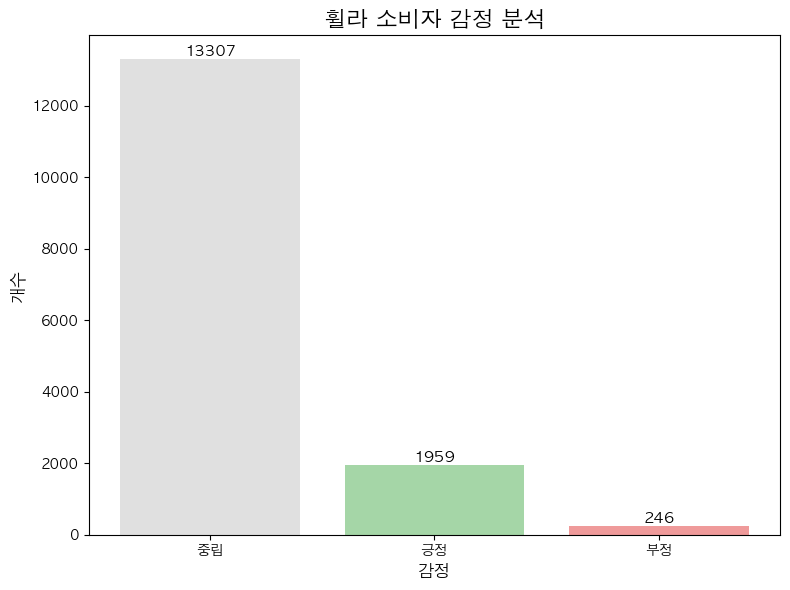

In [27]:
colors = ['#E0E0E0', '#A5D6A7', '#EF9A9A', ]

sentiment_counts = df_real['sentiment'].value_counts()

plt.figure(figsize=(8,6))

bars = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=colors
)

# 제목 & 라벨
plt.title("휠라 소비자 감정 분석", fontsize=16, fontweight='bold')
plt.xlabel("감정", fontsize=12)
plt.ylabel("개수", fontsize=12)

# 숫자 표시 (중요 ⭐)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- 감정 분석은 브랜드 이미지가 도출 불가
- 키워드/토픽 분석으로 방식 변경

In [29]:
custom_stopwords = [
    "휠라", "fila", "브랜드", "제품", "신발", "운동화",
    "사이즈", "구매", "배송", "후기", "리뷰"
]

In [30]:
vectorizer_model = CountVectorizer(
    ngram_range=(1,2),
    stop_words=custom_stopwords,
    min_df=5
)

In [31]:
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5337.25it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [33]:
topic_model = BERTopic(
    embedding_model=model,
    vectorizer_model=vectorizer_model,
    nr_topics=8,
    top_n_words=10
)

topics, probs = topic_model.fit_transform(docs)

/Users/hs/SPARTA_PROJECT_4TH_E_COMMERCE/.venv/lib/python3.13/site-packages/umap/spectral.py:519: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  eigenvalues, eigenvectors = scipy.sparse.linalg.eigsh(
/Users/hs/SPARTA_PROJECT_4TH_E_COMMERCE/.venv/lib/python3.13/site-packages/umap/spectral.py:519: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  eigenvalues, eigenvectors = scipy.sparse.linalg.eigsh(


TypeError: Cannot use scipy.linalg.eigh for sparse A with k >= N. Use scipy.linalg.eigh(A.toarray()) or reduce k.

- 안돼서 포기^^.